In [2]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
import os
import re
from tqdm import tqdm

data_path = './data'
os.listdir(data_path)

['microgrid_steady_state_rms_islanded',
 'microgrid_fault_dataset_rms',
 'All_DER_outage_grid_fault_CSV',
 'microgrid_steady_state_rms',
 'All_DER_outage_islanded_fault_CSV']

In [9]:
edge_index = torch.tensor([
    [0, 1, 1, 2, 4],
    [1, 3, 2, 4, 3]
])

edge_index_bi = np.concatenate((edge_index, torch.flip(edge_index, [0])), axis=1)

print("Bidirectional Edge Index:\n", edge_index_bi)

Bidirectional Edge Index:
 [[0 1 1 2 4 1 3 2 4 3]
 [1 3 2 4 3 0 1 1 2 4]]


In [10]:
mfdrI = os.path.join(data_path, 'microgrid_fault_dataset_rms', 'ICaseNum_rms_{}Results.csv')
mssrI = os.path.join(data_path, 'microgrid_steady_state_rms', 'ICaseNum_rms_{}Results.csv')

mfdrV = os.path.join(data_path, 'microgrid_fault_dataset_rms', 'VCaseNum_rms_{}Results.csv')
mssrV = os.path.join(data_path, 'microgrid_steady_state_rms', 'VCaseNum_rms_{}Results.csv')

In [11]:
num = np.random.randint(1, 2520)

print(num)
# num = 727
mfdrI_df = pd.read_csv(mfdrI.format(num), index_col=False)
mfdrV_df = pd.read_csv(mfdrV.format(num), index_col=False)

mfdrI_df.shape, mfdrV_df.shape

543


((1334, 25), (1334, 19))

In [12]:
mfdrV_df.describe()

,Time(sec),FaultLine,FaultType,FaultLoc,N16_rms[kV],N17_rms[kV],N18_rms[kV],N19_rms[kV],N1_rms[kV],N20_rms[kV],N21_rms[kV],N2_rms[kV],N3_rms[kV],N4_rms[kV],N5_rms[kV],N6_rms[kV],N7_rms[kV],N8_rms[kV],N9_rms[kV]
count,1334.000000,1334.0,1334.0,1.334000e+03,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000
mean,0.049987,4.0,2.0,1.000000e-06,6.947875,7.095661,7.470118,7.046199,7.524574,7.117812,7.494396,7.510739,7.598489,6.949349,7.241033,7.405665,7.002034,7.156167,7.451486
std,0.028893,0.0,0.0,9.532694e-21,0.416303,0.081220,0.008463,0.369805,0.051519,0.109855,0.015791,0.029851,0.026155,0.426904,0.016569,0.039865,0.392779,0.074278,0.010265
min,0.000000,4.0,2.0,1.000000e-06,6.591205,6.997887,7.443788,6.728363,7.480162,6.993183,7.474758,7.482117,7.563170,6.567965,7.206210,7.349143,6.659709,7.063741,7.421545
25%,0.024994,4.0,2.0,1.000000e-06,6.611080,7.027826,7.466363,6.744407,7.483659,7.025887,7.475202,7.485168,7.563199,6.611719,7.235237,7.369414,6.686875,7.094617,7.445511
50%,0.049988,4.0,2.0,1.000000e-06,6.650764,7.056374,7.472303,6.784937,7.488349,7.054798,7.497076,7.488856,7.620373,6.647291,7.247428,7.382003,6.723306,7.122880,7.457068
75%,0.074981,4.0,2.0,1.000000e-06,7.475324,7.205570,7.477325,7.514665,7.590470,7.267952,7.503791,7.551514,7.621529,7.489088,7.250883,7.457453,7.499569,7.256724,7.458292
max,0.099900,4.0,2.0,1.000000e-06,7.476148,7.206252,7.478845,7.515432,7.590566,7.268512,7.518273,7.551587,7.623410,7.489844,7.261849,7.457890,7.500325,7.257278,7.460136


In [13]:
num = np.random.randint(2521, 3127)

print(num)
mssrI_df = pd.read_csv(mssrI.format(num), index_col=False)
mssrV_df = pd.read_csv(mssrV.format(num), index_col=False)


mssrI_df.shape, mssrV_df.shape

3099


((1001, 30), (1001, 19))

In [14]:
mssrV_df.describe()

,Time(sec),FaultLine,FaultType,FaultLoc,N16_rms[kV],N17_rms[kV],N18_rms[kV],N19_rms[kV],N1_rms[kV],N20_rms[kV],N21_rms[kV],N2_rms[kV],N3_rms[kV],N4_rms[kV],N5_rms[kV],N6_rms[kV],N7_rms[kV],N8_rms[kV],N9_rms[kV]
count,1001.0,1001.0,1001.0,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,0.0,1.0,1.0,1.000000e-01,6.627697,6.227947,6.674421,6.792948,7.508136,6.441027,6.787040,7.450938,7.481615,6.778239,6.429161,6.783477,6.785587,6.436723,6.777204
std,0.0,0.0,0.0,1.416242e-15,0.001057,0.001194,0.001022,0.001055,0.000139,0.001171,0.001034,0.000157,0.000143,0.000976,0.001094,0.000954,0.001016,0.001132,0.000996
min,0.0,1.0,1.0,1.000000e-01,6.625832,6.225735,6.672543,6.791092,7.507890,6.438847,6.785143,7.450671,7.481347,6.776513,6.427134,6.781738,6.783791,6.434614,6.775388
25%,0.0,1.0,1.0,1.000000e-01,6.626787,6.226833,6.673485,6.792046,7.508015,6.439922,6.786092,7.450813,7.481478,6.777395,6.428138,6.782614,6.784710,6.435652,6.776303
50%,0.0,1.0,1.0,1.000000e-01,6.627714,6.227894,6.674390,6.792971,7.508137,6.440962,6.787006,7.450950,7.481605,6.778250,6.429109,6.783457,6.785600,6.436658,6.777183
75%,0.0,1.0,1.0,1.000000e-01,6.628614,6.228919,6.675266,6.793867,7.508255,6.441968,6.787890,7.451083,7.481727,6.779080,6.430048,6.784273,6.786464,6.437630,6.778035
max,0.0,1.0,1.0,1.000000e-01,6.629485,6.229910,6.676115,6.794737,7.508370,6.442940,6.788747,7.451188,7.481845,6.779885,6.430956,6.785064,6.787302,6.438569,6.778862


In [15]:
mssrI_df.columns , mfdrI_df.columns

(Index(['Time(sec)', 'FAULT_LINE', 'FAULT_TYPE', 'WIND_SPD', 'INSOL_LVL',
        'LINE_LENGTH', 'I121A_rms[kA]', 'I121B_rms[kA]', 'I121C_rms[kA]',
        'I232A_rms[kA]', 'I232B_rms[kA]', 'I232C_rms[kA]', 'I264A_rms[kA]',
        'I264B_rms[kA]', 'I264C_rms[kA]', 'I343A_rms[kA]', 'I343B_rms[kA]',
        'I343C_rms[kA]', 'I656A_rms[kA]', 'I656B_rms[kA]', 'I656C_rms[kA]',
        'I765A_rms[kA]', 'I765B_rms[kA]', 'I765C_rms[kA]', 'S3IA_rms[kA]',
        'S3IB_rms[kA]', 'S3IC_rms[kA]', 'LOAD_5', 'LOAD_6', 'LOAD_7'],
       dtype='object'),
 Index(['Time(sec)', 'FAULT_LINE', 'FAULT_TYPE', 'LINE_LENGTH', 'I121A_rms[kA]',
        'I121B_rms[kA]', 'I121C_rms[kA]', 'I232A_rms[kA]', 'I232B_rms[kA]',
        'I232C_rms[kA]', 'I264A_rms[kA]', 'I264B_rms[kA]', 'I264C_rms[kA]',
        'I343A_rms[kA]', 'I343B_rms[kA]', 'I343C_rms[kA]', 'I656A_rms[kA]',
        'I656B_rms[kA]', 'I656C_rms[kA]', 'I765A_rms[kA]', 'I765B_rms[kA]',
        'I765C_rms[kA]', 'S3IA_rms[kA]', 'S3IB_rms[kA]', 'S3IC_rms[kA

In [16]:
mssr_df = pd.concat([mssrV_df, mssrI_df], axis=1)
mfdr_df = pd.concat([mfdrV_df, mfdrI_df], axis=1)

In [17]:

mssr_df.columns

Index(['Time(sec)', 'FaultLine', 'FaultType', 'FaultLoc', 'N16_rms[kV]',
       'N17_rms[kV]', 'N18_rms[kV]', 'N19_rms[kV]', 'N1_rms[kV]',
       'N20_rms[kV]', 'N21_rms[kV]', 'N2_rms[kV]', 'N3_rms[kV]', 'N4_rms[kV]',
       'N5_rms[kV]', 'N6_rms[kV]', 'N7_rms[kV]', 'N8_rms[kV]', 'N9_rms[kV]',
       'Time(sec)', 'FAULT_LINE', 'FAULT_TYPE', 'WIND_SPD', 'INSOL_LVL',
       'LINE_LENGTH', 'I121A_rms[kA]', 'I121B_rms[kA]', 'I121C_rms[kA]',
       'I232A_rms[kA]', 'I232B_rms[kA]', 'I232C_rms[kA]', 'I264A_rms[kA]',
       'I264B_rms[kA]', 'I264C_rms[kA]', 'I343A_rms[kA]', 'I343B_rms[kA]',
       'I343C_rms[kA]', 'I656A_rms[kA]', 'I656B_rms[kA]', 'I656C_rms[kA]',
       'I765A_rms[kA]', 'I765B_rms[kA]', 'I765C_rms[kA]', 'S3IA_rms[kA]',
       'S3IB_rms[kA]', 'S3IC_rms[kA]', 'LOAD_5', 'LOAD_6', 'LOAD_7'],
      dtype='object')

In [18]:
node_features = ['N1_rms[kV]', 'N2_rms[kV]', 'N3_rms[kV]',    # node 1: 0
                 'N4_rms[kV]', 'N5_rms[kV]', 'N6_rms[kV]',    # node 2: 1
                 'N7_rms[kV]', 'N8_rms[kV]', 'N9_rms[kV]',    # node 3: 2
                 'N16_rms[kV]','N17_rms[kV]', 'N18_rms[kV]',  # node 6: 3
                 'N19_rms[kV]',  'N20_rms[kV]', 'N21_rms[kV]']# node 7: 4
                   
edge_features = ['I121A_rms[kA]', 'I121B_rms[kA]', 'I121C_rms[kA]',  # TL 1-2
                 'I232A_rms[kA]', 'I232B_rms[kA]', 'I232C_rms[kA]',  # TL 2-3 
                 'I264A_rms[kA]', 'I264B_rms[kA]', 'I264C_rms[kA]',  # TL 2-6
                 'I765A_rms[kA]', 'I765B_rms[kA]', 'I765C_rms[kA]',  # TL 7-6
                 'S3IA_rms[kA]', 'S3IB_rms[kA]', 'S3IC_rms[kA]']     # TL 3-7

print('Total node features:', len(node_features))
print('Total edge features:', len(edge_features))

Total node features: 15
Total edge features: 15


In [19]:
# microgrid_steady_state_rms
window_size = 200
edge_data = torch.tensor(mssr_df[edge_features].apply(lambda col: col.fillna(col.mean()), axis=0).to_numpy())
print(edge_data.size(), edge_data.unfold(0, window_size, 1).size())
edge_data = edge_data.unfold(0, window_size, 1).view(-1, 5, 3, window_size).transpose(-1, -2) #.view(-1, window_size, 5, 3) # (-1, time, nodes, features)
print(edge_data.size())


# node_data = torch.tensor(mssr_df[node_features].to_numpy())
# node_data = node_data.unfold(0, window_size, 1).transpose(-1, -2).view(-1, window_size, 5, 3) # (-1, time, nodes, features)
# print(node_data.size())


torch.Size([1001, 15]) torch.Size([802, 15, 200])
torch.Size([802, 5, 200, 3])


In [20]:
mssr_df[edge_features].head()

,I121A_rms[kA],I121B_rms[kA],I121C_rms[kA],I232A_rms[kA],I232B_rms[kA],I232C_rms[kA],I264A_rms[kA],I264B_rms[kA],I264C_rms[kA],I765A_rms[kA],I765B_rms[kA],I765C_rms[kA],S3IA_rms[kA],S3IB_rms[kA],S3IC_rms[kA]
0,0.300205,0.375335,0.277698,0.069925,0.056454,0.026655,0.241554,0.317429,0.231903,0.225206,0.278719,0.217582,0.103882,0.105733,0.077531
1,0.300205,0.375335,0.277698,0.069925,0.056454,0.026655,0.241554,0.317429,0.231903,0.225206,0.278719,0.217582,0.103882,0.105733,0.077531
2,0.300205,0.375335,0.277698,0.069925,0.056454,0.026655,0.241554,0.317429,0.231903,0.225206,0.278719,0.217582,0.103882,0.105733,0.077531
3,0.300205,0.375335,0.277698,0.069925,0.056454,0.026655,0.241554,0.317429,0.231903,0.225206,0.278719,0.217582,0.103882,0.105733,0.077531
4,0.300205,0.375310,0.277698,0.069925,0.056454,0.026655,0.241554,0.317429,0.231903,0.225206,0.278719,0.217582,0.103882,0.105733,0.077531


In [21]:
torch.app

AttributeError: module 'torch' has no attribute 'app'

In [ ]:
# microgrid_fault_dataset_rms
window_size = 200
edge_data = torch.tensor(mfdr_df[edge_features].to_numpy())
edge_data = edge_data.unfold(0, window_size, 1).transpose(-1, -2).view(-1, window_size, 5, 3) # (-1, time, nodes, features)
print('Edge data shape:', edge_data.size())

node_data = torch.tensor(mfdr_df[node_features].to_numpy())
node_data = node_data.unfold(0, window_size, 1).transpose(-1, -2).view(-1, window_size, 5, 3) # (-1, time, nodes, features)
print('Node data shape:', node_data.size())

labels = torch.tensor(np.repeat(mfdr_df.FAULT_TYPE.loc[0].astype(int), node_data.size(0), axis=0))
print('Label shape:', labels.size())

Edge data shape: torch.Size([1135, 200, 5, 3])
Node data shape: torch.Size([1135, 200, 5, 3])
Label shape: torch.Size([1135])


In [38]:
type(edge_index), type(edge_index_bi)

(torch.Tensor, numpy.ndarray)

In [3]:
from torch_geometric.data import Data, DataLoader

mfdrI = os.path.join(data_path, 'microgrid_fault_dataset_rms', 'ICaseNum_rms_{}Results.csv')
mssrI = os.path.join(data_path, 'microgrid_steady_state_rms', 'ICaseNum_rms_{}Results.csv')

mfdrV = os.path.join(data_path, 'microgrid_fault_dataset_rms', 'VCaseNum_rms_{}Results.csv')
mssrV = os.path.join(data_path, 'microgrid_steady_state_rms', 'VCaseNum_rms_{}Results.csv')


node_features = ['N1_rms[kV]', 'N2_rms[kV]', 'N3_rms[kV]',    # node 1: 0
                 'N4_rms[kV]', 'N5_rms[kV]', 'N6_rms[kV]',    # node 2: 1
                 'N7_rms[kV]', 'N8_rms[kV]', 'N9_rms[kV]',    # node 3: 2
                 'N16_rms[kV]','N17_rms[kV]', 'N18_rms[kV]',  # node 6: 3
                 'N19_rms[kV]',  'N20_rms[kV]', 'N21_rms[kV]']# node 7: 4
                   
edge_features = ['I121A_rms[kA]', 'I121B_rms[kA]', 'I121C_rms[kA]',  # TL 1-2
                 'I232A_rms[kA]', 'I232B_rms[kA]', 'I232C_rms[kA]',  # TL 2-3 
                 'I264A_rms[kA]', 'I264B_rms[kA]', 'I264C_rms[kA]',  # TL 2-6
                 'I765A_rms[kA]', 'I765B_rms[kA]', 'I765C_rms[kA]',  # TL 7-6
                 'S3IA_rms[kA]', 'S3IB_rms[kA]', 'S3IC_rms[kA]']     # TL 3-7

print('Total node features:', len(node_features))
print('Total edge features:', len(edge_features))

def extract_data(data_name, window_size, stride, n_nodes, n_edges, n_node_features, n_edge_features, case_range=None):
    csv_file_path = os.path.join(data_path, data_name)
    print(f'Preparing data from {data_name}')
    data_files = os.listdir(csv_file_path)

    current_pattern = re.compile(r'ICaseNum_rms_\d+Results.csv')
    # voltage_pattern = re.compile(r'VCaseNum_rms_\d+Results.csv')
    edge_index = torch.tensor([
                    [0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
                    [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]
                ])

    # edge_index_bi = torch.tensor(np.concatenate((edge_index, torch.flip(edge_index, [0])), axis=1))
    # edge_index_bi = torch.cat((edge_index, torch.flip(edge_index, [0])), dim=1)

    edge_dataset = torch.empty(0, n_edges, window_size, n_edge_features).to(torch.float32)
    node_dataset = torch.empty(0, n_nodes, window_size, n_node_features).to(torch.float32)
    label_dataset = torch.empty(0).to(torch.int8)

    for file in tqdm(data_files, desc='Processing Data Files', total=len(data_files)): 
        if current_pattern.fullmatch(file):
            case_number = int(re.findall(f'\d+', file)[0])

            if (case_range is not None) and (not case_range[0]<=case_number<=case_range[1]):
                continue

            current_df = pd.read_csv(os.path.join(csv_file_path, file), index_col=False)
            voltage_df = pd.read_csv(os.path.join(csv_file_path, f'VCaseNum_rms_{case_number}Results.csv'), index_col=False)

            edge_data = torch.tensor(current_df[edge_features].apply(lambda col: col.fillna(col.mean()), axis=0).to_numpy())
            # print(edge_data.unfold(0, window_size, stride).size())
            edge_data = edge_data.unfold(0, window_size, stride).view(-1, n_edges, n_edge_features, window_size).transpose(-1, -2) # (-1, edges, time, edge_features)
            edge_data = edge_data.to(torch.float64)
            # print('Edge data shape:', edge_data.size())

            node_data = torch.tensor(voltage_df[node_features].apply(lambda col: col.fillna(col.mean()), axis=0).to_numpy())
            node_data = node_data.unfold(0, window_size, stride).view(-1, n_nodes, n_node_features, window_size).transpose(-1, -2) # (-1, nodes, time, node_features)
            node_data = node_data.to(torch.float64)
            # print('Node data shape:', node_data.size())

            labels = torch.tensor(np.repeat(current_df.FAULT_TYPE.loc[0].astype(int), node_data.size(0), axis=0)) # (-1)
            labels = labels.to(torch.int8)
            # print('Label shape:', labels.size())

            edge_dataset = torch.concat((edge_dataset, edge_data), dim=0)
            node_dataset = torch.concat((node_dataset, node_data), dim=0)
            label_dataset = torch.concat((label_dataset, labels), dim=0)


    edge_memory = (edge_dataset.element_size() * edge_dataset.nelement()) / (1024 ** 2)
    print(f'\nEdge Dataset: {edge_dataset.size()}, {edge_memory:.2f} MB')
    node_memory = (node_dataset.element_size() * node_dataset.nelement()) / (1024 ** 2)
    print(f'Node Dataset: {node_dataset.size()}, {node_memory:.2f} MB')
    label_memory = (label_dataset.element_size() * label_dataset.nelement()) / (1024 ** 2)
    print(f'Label Dataset: {label_dataset.size()}, {label_memory:.2f} MB')

    ndata = edge_dataset.size(0)
    dataset = []

    for i in tqdm(range(ndata), desc='Building Graph Dataset'):
        dataset.append(Data(x=node_dataset[i], edge_index=edge_index, edge_attr=edge_dataset[i], y=label_dataset[i]))

    return dataset


Total node features: 15
Total edge features: 15


In [4]:
data = extract_data('microgrid_steady_state_rms', 400, 4, 5, 5, 3, 3, case_range=(2521, 2600))

Preparing data from microgrid_steady_state_rms


Processing Data Files: 100%|██████████| 1214/1214 [00:07<00:00, 168.40it/s]



Edge Dataset: torch.Size([12080, 5, 400, 3]), 552.98 MB
Node Dataset: torch.Size([12080, 5, 400, 3]), 552.98 MB
Label Dataset: torch.Size([12080]), 0.01 MB


Building Graph Dataset: 100%|██████████| 12080/12080 [00:00<00:00, 40747.11it/s]


In [41]:
edge_index.shape, type(edge_index)

(torch.Size([2, 5]), torch.Tensor)

In [8]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

dataloader = DataLoader(data, batch_size=1, shuffle=True)

for batch in dataloader:
    print(batch)
    print(batch.x.size())
    # print(batch.edge_index)
    print(batch.edge_attr.size())
    
    break
# DataLoader()

DataBatch(x=[5, 400, 3], edge_index=[2, 10], edge_attr=[5, 400, 3], y=[1], batch=[5], ptr=[2])
torch.Size([5, 400, 3])
torch.Size([5, 400, 3])


In [9]:
dataloader.batch_size

1

In [7]:
batch.y-1

tensor([0], dtype=torch.int8)

In [45]:
edge_index

tensor([[0, 1, 1, 2, 4],
        [1, 3, 2, 4, 3]])

In [ ]:
from layers import GraphTransformerLayer, GraphTransformer

num_nodes = 5
in_dim = 32
d_model = 32
num_heads = 2
num_edges = 5
edge_attr_dim = 3
interval = 400

model = GraphTransformer(d_model, num_nodes, num_heads, in_dim, edge_attr_dim, 0.1, True, num_layers=2)
model.eval()




In [26]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# Example graph data
x1 = torch.randn(5, 16)  # Node features for graph 1
edge_index1 = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]], dtype=torch.long)  # Edge index for graph 1

x2 = torch.randn(3, 16)  # Node features for graph 2
edge_index2 = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)  # Edge index for graph 2

data1 = Data(x=x1, edge_index=edge_index1)
data2 = Data(x=x2, edge_index=edge_index2)

# Create a list of graphs
data_list = [data1, data2]

# Use DataLoader to batch graphs
loader = DataLoader(data_list, batch_size=2)

# Now, each batch will have edge_index adjusted correctly
batch = next(iter(loader))
print(batch.edge_index.shape)  # This will be (2, total_edges)


torch.Size([2, 6])


In [25]:
batch.edge_index

[array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]]),
 array([[0, 1, 1, 2, 4, 1, 3, 2, 4, 3],
        [1, 3, 2, 4, 3, 0, 1, 1, 2, 4]])]

In [159]:
import torch

tensor = torch.rand(1135, 200, 5, 3)

# Calculate memory in MB
memory_MB = (edge_dataset.element_size() * edge_dataset.nelement()) / (1024 ** 2)

print(f"Memory consumed: {memory_MB:.2f} MB")


Memory consumed: 4818.94 MB


In [26]:
import torch
from torch_geometric.data import Data, DataLoader

# Example data shapes
x_data = torch.rand(48160, 400, 5, 3)      # Node features
edge_index_data = torch.randint(0, 400, (2, 48160))  # Random edge indices
edge_attr_data = torch.rand(48160, 400, 5, 3)  # Edge features

# Convert to a list of Data objects
data_list = []
for i in range(48160):
    data = Data(
        x=x_data[i], 
        edge_index=edge_index_data[:, i].unsqueeze(1), 
        edge_attr=edge_attr_data[i]
    )
    data_list.append(data)

print(f"Created {len(data_list)} graph data objects.")


Created 48160 graph data objects.


In [27]:
loader = DataLoader(data_list, batch_size=64, shuffle=True)

for batch in loader:
    print(batch)
    print("Batch node features shape:", batch.x.shape)
    print("Batch edge index shape:", batch.edge_index.shape)
    print("Batch edge features shape:", batch.edge_attr.shape)


/home/rtds/miniconda3/envs/power/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


DataBatch(x=[25600, 5, 3], edge_index=[2, 64], edge_attr=[25600, 5, 3], batch=[25600], ptr=[65])
Batch node features shape: torch.Size([25600, 5, 3])
Batch edge index shape: torch.Size([2, 64])
Batch edge features shape: torch.Size([25600, 5, 3])
DataBatch(x=[25600, 5, 3], edge_index=[2, 64], edge_attr=[25600, 5, 3], batch=[25600], ptr=[65])
Batch node features shape: torch.Size([25600, 5, 3])
Batch edge index shape: torch.Size([2, 64])
Batch edge features shape: torch.Size([25600, 5, 3])
DataBatch(x=[25600, 5, 3], edge_index=[2, 64], edge_attr=[25600, 5, 3], batch=[25600], ptr=[65])
Batch node features shape: torch.Size([25600, 5, 3])
Batch edge index shape: torch.Size([2, 64])
Batch edge features shape: torch.Size([25600, 5, 3])
DataBatch(x=[25600, 5, 3], edge_index=[2, 64], edge_attr=[25600, 5, 3], batch=[25600], ptr=[65])
Batch node features shape: torch.Size([25600, 5, 3])
Batch edge index shape: torch.Size([2, 64])
Batch edge features shape: torch.Size([25600, 5, 3])
DataBatch(x=

In [69]:
mfdr_df.columns

Index(['Time(sec)', 'FaultLine', 'FaultType', 'FaultLoc', 'N16_rms[kV]',
       'N17_rms[kV]', 'N18_rms[kV]', 'N19_rms[kV]', 'N1_rms[kV]',
       'N20_rms[kV]', 'N21_rms[kV]', 'N2_rms[kV]', 'N3_rms[kV]', 'N4_rms[kV]',
       'N5_rms[kV]', 'N6_rms[kV]', 'N7_rms[kV]', 'N8_rms[kV]', 'N9_rms[kV]',
       'Time(sec)', 'FAULT_LINE', 'FAULT_TYPE', 'LINE_LENGTH', 'I121A_rms[kA]',
       'I121B_rms[kA]', 'I121C_rms[kA]', 'I232A_rms[kA]', 'I232B_rms[kA]',
       'I232C_rms[kA]', 'I264A_rms[kA]', 'I264B_rms[kA]', 'I264C_rms[kA]',
       'I343A_rms[kA]', 'I343B_rms[kA]', 'I343C_rms[kA]', 'I656A_rms[kA]',
       'I656B_rms[kA]', 'I656C_rms[kA]', 'I765A_rms[kA]', 'I765B_rms[kA]',
       'I765C_rms[kA]', 'S3IA_rms[kA]', 'S3IB_rms[kA]', 'S3IC_rms[kA]'],
      dtype='object')

In [53]:
mssr_df.FaultType.head(1), mssr_df.FAULT_TYPE.head(1)

(0    1.0
 Name: FaultType, dtype: float64,
 0    1.0
 Name: FAULT_TYPE, dtype: float64)

In [70]:
mfdr_df.FaultType.head(1), mfdr_df.FAULT_TYPE.head(1)

(0    5.0
 Name: FaultType, dtype: float64,
 0    5.0
 Name: FAULT_TYPE, dtype: float64)

In [55]:
mfdrI_df.head()

,Time(sec),FAULT_LINE,FAULT_TYPE,LINE_LENGTH,I121A_rms[kA],I121B_rms[kA],I121C_rms[kA],I232A_rms[kA],I232B_rms[kA],I232C_rms[kA],...,I343C_rms[kA],I656A_rms[kA],I656B_rms[kA],I656C_rms[kA],I765A_rms[kA],I765B_rms[kA],I765C_rms[kA],S3IA_rms[kA],S3IB_rms[kA],S3IC_rms[kA]
0,0.000000,4.0,4.0,0.200001,0.020612,0.084811,0.077712,0.041613,0.039575,0.061608,...,0.045405,0.031451,0.055351,0.05663,0.042047,0.07939,0.040288,0.064786,0.038666,0.064775
1,0.000075,4.0,4.0,0.200001,0.020612,0.084811,0.077712,0.041613,0.039575,0.061608,...,0.045405,0.031451,0.055351,0.05663,0.042047,0.07939,0.040288,0.064786,0.038666,0.064775
2,0.000150,4.0,4.0,0.200001,0.020612,0.084811,0.077712,0.041613,0.039575,0.061608,...,0.045405,0.031451,0.055351,0.05663,0.042047,0.07939,0.040288,0.064786,0.038666,0.064775
3,0.000225,4.0,4.0,0.200001,0.020612,0.084811,0.077712,0.041613,0.039575,0.061608,...,0.045405,0.031451,0.055351,0.05663,0.042047,0.07939,0.040288,0.064786,0.038666,0.064775
4,0.000300,4.0,4.0,0.200001,0.020612,0.084811,0.077712,0.041613,0.039575,0.061608,...,0.045405,0.031451,0.055351,0.05663,0.042047,0.07939,0.040288,0.064786,0.038666,0.064775


In [54]:
mfdrV_df.head()

,Time(sec),FaultLine,FaultType,FaultLoc,N16_rms[kV],N17_rms[kV],N18_rms[kV],N19_rms[kV],N1_rms[kV],N20_rms[kV],N21_rms[kV],N2_rms[kV],N3_rms[kV],N4_rms[kV],N5_rms[kV],N6_rms[kV],N7_rms[kV],N8_rms[kV],N9_rms[kV]
0,0.000000,4.0,4.0,0.200001,7.476153,7.206272,7.473151,7.515431,7.590566,7.268518,7.475567,7.551586,7.563281,7.48984,7.250876,7.458178,7.500323,7.257278,7.457868
1,0.000075,4.0,4.0,0.200001,7.476153,7.206272,7.473151,7.515431,7.590566,7.268518,7.475567,7.551586,7.563281,7.48984,7.250876,7.458178,7.500323,7.257278,7.457868
2,0.000150,4.0,4.0,0.200001,7.476153,7.206272,7.473151,7.515431,7.590566,7.268518,7.475567,7.551586,7.563281,7.48984,7.250876,7.458178,7.500323,7.257278,7.457868
3,0.000225,4.0,4.0,0.200001,7.476153,7.206272,7.473151,7.515431,7.590566,7.268518,7.475567,7.551586,7.563281,7.48984,7.250876,7.458178,7.500323,7.257278,7.457868
4,0.000300,4.0,4.0,0.200001,7.476153,7.206272,7.473151,7.515431,7.590566,7.268518,7.475567,7.551586,7.563281,7.48984,7.250876,7.458178,7.500323,7.257278,7.457868


In [66]:
mssrV_df.head()

,Time(sec),FaultLine,FaultType,FaultLoc,N16_rms[kV],N17_rms[kV],N18_rms[kV],N19_rms[kV],N1_rms[kV],N20_rms[kV],N21_rms[kV],N2_rms[kV],N3_rms[kV],N4_rms[kV],N5_rms[kV],N6_rms[kV],N7_rms[kV],N8_rms[kV],N9_rms[kV]
0,0.0,1.0,1.0,0.1,6.18174,5.638472,6.243312,6.407529,7.456614,5.947477,6.409904,7.384069,7.429011,6.396963,5.931312,6.411845,6.401821,5.943406,6.401751
1,0.0,1.0,1.0,0.1,6.18174,5.638472,6.243312,6.407529,7.456614,5.947477,6.409904,7.384069,7.429011,6.396963,5.931312,6.411845,6.401821,5.943406,6.401751
2,0.0,1.0,1.0,0.1,6.18174,5.638472,6.243312,6.407529,7.456614,5.947477,6.409904,7.384069,7.429011,6.396963,5.931312,6.411845,6.401821,5.943406,6.401751
3,0.0,1.0,1.0,0.1,6.18174,5.638472,6.243312,6.407529,7.456614,5.947477,6.409904,7.384069,7.429011,6.396963,5.931312,6.411845,6.401821,5.943406,6.401751
4,0.0,1.0,1.0,0.1,6.18174,5.638472,6.243312,6.407529,7.456614,5.947477,6.409904,7.384069,7.429011,6.396963,5.931312,6.411845,6.401821,5.943406,6.401751


In [67]:
mssrI_df.head()

,Time(sec),FAULT_LINE,FAULT_TYPE,WIND_SPD,INSOL_LVL,LINE_LENGTH,I121A_rms[kA],I121B_rms[kA],I121C_rms[kA],I232A_rms[kA],...,I656C_rms[kA],I765A_rms[kA],I765B_rms[kA],I765C_rms[kA],S3IA_rms[kA],S3IB_rms[kA],S3IC_rms[kA],LOAD_5,LOAD_6,LOAD_7
0,0.0,1.0,1.0,10.0,950.0,0.1,0.47633,0.557204,0.4359,0.146013,...,0.069032,0.31885,0.394489,0.312962,0.169885,0.175058,0.138016,0.309,3.119,0.261
1,0.0,1.0,1.0,10.0,950.0,0.1,0.47633,0.557204,0.4359,0.146013,...,0.069032,0.31885,0.394489,0.312962,0.169885,0.175058,0.138036,0.309,3.119,0.261
2,0.0,1.0,1.0,10.0,950.0,0.1,0.47633,0.557204,0.4359,0.146013,...,0.069032,0.31885,0.394489,0.312962,0.169885,0.175058,0.138036,0.309,3.119,0.261
3,0.0,1.0,1.0,10.0,950.0,0.1,0.47633,0.557204,0.4359,0.146013,...,0.069032,0.31885,0.394489,0.312962,0.169885,0.175058,0.138036,0.309,3.119,0.261
4,0.0,1.0,1.0,10.0,950.0,0.1,0.47633,0.557204,0.4359,0.146013,...,0.069032,0.31885,0.394489,0.312962,0.169885,0.175058,0.138036,0.309,3.119,0.261


In [ ]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
import os
import re

# ref: https://www.youtube.com/watch?v=Sj-gIb0QiRM

# data_path = os.path.join('./data', 'microgrid_steady_state_rms')
# data_files = os.listdir(data_path)

# current_pattern = re.compile(r'ICaseNum_rms_\d+Results.csv')
# voltage_pattern = re.compile(r'VCaseNum_rms_\d+Results.csv')

# for file in data_files:
#     if current_pattern.fullmatch(file):
#         df = pd.read_csv(file)



edge_index = torch.tensor([
    [0, 1, 1, 2, 6],
    [1, 5, 2, 6, 5]
])
reversed_edges = edge_index[::-1]
edge_index_bi = np.concatenate((edge_index, reversed_edges), axis=1)

print("Bidirectional Edge Index:\n", edge_index_bi)

# class PowerSystemDataset(Dataset):
#     def __init__(self):
#         super().__init__()
#         self.dataset = 

#     def __len__(self):
#         return len(self.dataset)
    
#     def __getitem__(self, index):
        
                

#     def load_dataset(self):
#         pass



import torch
from layers import GraphTransformerLayer, GraphTransformer

num_nodes = 10
in_dim = 32
d_model = 32
num_heads = 2
num_edges = 20
edge_attr_dim = 64
interval = 8
"""
expected shape
    x: (n_nodes, time, node_features)
    edge_index: (2, n_edges)
    edge_attr: (n_edges, time, edge_features)
"""
x = torch.randn((num_nodes, interval, in_dim))
edge_index = torch.randint(0, num_nodes, (2, num_edges))
edge_attr = torch.randn((num_edges, interval, edge_attr_dim))

print('Input data dimension')
print(f'x: {x.size()}')
print(f'edge_index: {edge_index.size()}')
print(f'edge_attr: {edge_attr.size()}')


# model = GraphTransformerLayer(
#     in_dim = in_dim,
#     out_dim = out_dim,
#     num_heads = 4,
#     dropout = 0.2,
#     layer_norm = True,
#     batch_norm = False,
#     residual = True,
#     use_bias = False
# )

# model = GraphTransformerLayer(
#     d_model, num_heads, node_features=in_dim, edge_features=edge_attr_dim, dropout=0.1, use_bias=True
# )

model = GraphTransformer(d_model, num_nodes, num_heads, in_dim, edge_attr_dim, 0.1, True, num_layers=2)
model.eval()

h = model(x, edge_index, edge_attr)

Bidirectional Edge Index:
 [[0 1 1 2 4 1 3 2 4 3]
 [1 3 2 4 3 0 1 1 2 4]]


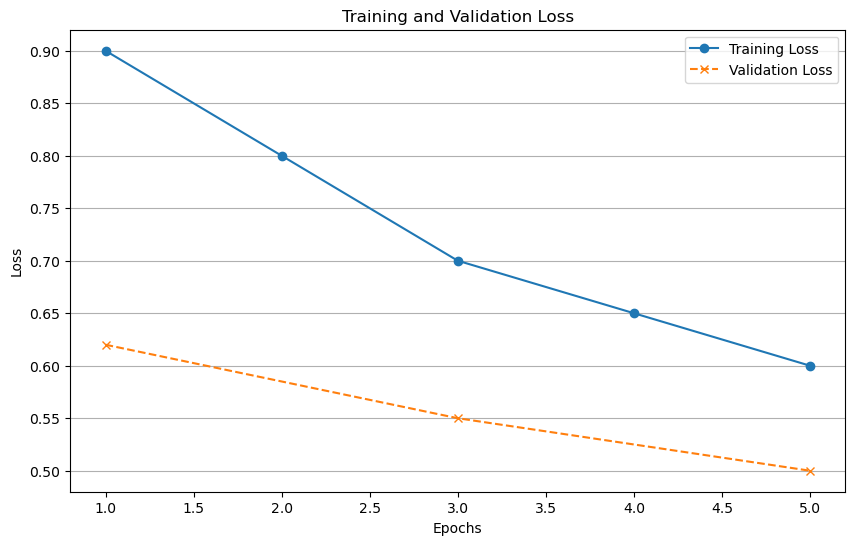

In [ ]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses, save_path):
    train_epochs, train_loss_values = zip(*train_losses)
    val_epochs, val_loss_values = zip(*val_losses)

    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_loss_values, label='Training Loss', marker='o', linestyle='-')
    plt.plot(val_epochs, val_loss_values, label='Validation Loss', marker='x', linestyle='--')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, axis='y')

    plt.savefig(save_path)
    plt.close()

# Example usage
train_losses = [(1, 0.9), (2, 0.8), (3, 0.7), (4, 0.65), (5, 0.6)]
val_losses = [(1, 0.62), (3, 0.55), (5, 0.50)]
plot_losses(train_losses, val_losses)


In [1]:
import torch
import torch.nn as nn

n_nodes = 5
x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print("Original Tensor:", x)

# Initialize LayerNorm
layer_norm = nn.LayerNorm(normalized_shape=n_nodes)

# Apply LayerNorm
output = layer_norm(x)
print("After LayerNorm:", output)


Original Tensor: tensor([1., 2., 3., 4., 5.])
After LayerNorm: tensor([-1.4142, -0.7071,  0.0000,  0.7071,  1.4142],
       grad_fn=<NativeLayerNormBackward0>)
